# 03.3 — Feature Engineering (Comment ↔ Original Post Relation)

Continues from `03.1`: loads its checkpoint (`comments_df` with the section 6 per-comment features, plus the running `untrusted_features` list) and computes the same style of features for each comment's original post (OP), to see whether a relation between a comment's features and its OP's features helps predict persuasion.

> Loads `results/comments_df_section6_checkpoint.csv` and `results/untrusted_features_section6_checkpoint.json` (output of `03.1`).

In [1]:
import pandas as pd, json

comments_df = pd.read_csv('../results/03_2_comments_df.csv')
with open('../results/03_2_untrusted_features.json') as f:
    untrusted_features = json.load(f)

print(comments_df.shape)
print(untrusted_features)

(3971, 215)
['sentiment_vader', 'tone_label', 'style_label', 'ethos_score', 'pathos_score', 'logos_score']


## Setup

The helpers and Gemini setup below come from `common_functions.py` (shared with `03.1`), so nothing here is duplicated by hand. The two feature functions and the LLM prompts are still printed inline so the actual methodology stays visible without opening that file.

In [2]:
import re
import numpy as np
import common_functions

In [3]:
genai_client = common_functions.make_gemini_client()
GEMINI_MODEL = common_functions.DEFAULT_GEMINI_MODEL
from google.genai import errors as genai_errors

print(f"Using Gemini model: {GEMINI_MODEL}")

Using Gemini model: gemini-flash-latest


In [4]:
sentiment_llm_prompt_prefix = common_functions.SENTIMENT_LLM_PROMPT_PREFIX
user_prompt_prefix = common_functions.TONE_LLM_PROMPT_PREFIX
rhetorical_llm_prompt_prefix = common_functions.RHETORICAL_LLM_PROMPT_PREFIX

print(sentiment_llm_prompt_prefix)
print(user_prompt_prefix)
print(rhetorical_llm_prompt_prefix)

Rate the sentiment of each of the following numbered texts on a scale from -1 (very negative) to 1 (very positive).

Base your score only on the tone and attitude of the person writing (e.g. hostile, dismissive, or rude vs. friendly, respectful, or warm) - NOT on how negative or positive the topic being discussed is. A calm, respectful discussion of a dark or violent topic should score close to neutral, not negative.

Reply with exactly one line per text, in the format "N: score" (matching the numbers below), and nothing else.

Texts:

Analyze the tone of each of the following numbered texts and classify it as one of the following: Logical, Passionate, Humorous, Sarcastic, Neutral, or Other.

Reply with exactly one line per text, in the format "N: label" (matching the numbers below), and nothing else.

Texts:

Rate each of the following numbered texts on three rhetorical appeals, each on a scale from 0 (not present) to 1 (strongly present):

- ethos: appeals to the author's credibility

In [5]:
do_calc_feature_op = common_functions.do_calc_feature_op

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

In [7]:
import inspect
print(inspect.getsource(common_functions.get_adjective_adverb_ratio))

get_adjective_adverb_ratio = common_functions.get_adjective_adverb_ratio

def get_adjective_adverb_ratio(text):
    doc = _get_nlp()(text)
    adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
    adverbs = [token.text for token in doc if token.pos_ == 'ADV']
    return len(adjectives) / len(adverbs) if len(adverbs) > 0 else np.inf



In [8]:
print("EVIDENCE_STEMS:", common_functions.EVIDENCE_STEMS)
print("EVIDENCE_URL_EXTENSIONS:", common_functions.EVIDENCE_URL_EXTENSIONS)
print()
print(inspect.getsource(common_functions.get_evidence_count))

get_evidence_count = common_functions.get_evidence_count

EVIDENCE_STEMS: ['data', 'stat', 'statist', 'figur', '%', 'percent', 'averag', 'number', 'amount', 'thousand', 'million', 'billion', '$', '€', '¥', '£', 'dollar', 'evid', 'info', 'testimoni', 'conclus', 'document', 'experi', 'experi', 'measur', 'measur', 'report', 'result', 'census', 'figur', 'plot', 'graph', 'sum', 'total', 'decim', 'digit', 'fraction', 'numer', 'half', 'share', 'proport', 'capit', 'cash', 'properti', 'salari', 'wage', 'wealth', 'financ', 'resourc', 'roll', 'treasuri', 'bank', 'deposit', 'exchang', 'safe', 'estim', 'price', 'price', 'merchandis', 'retail', 'sale', 'cartel', 'invest', 'market', 'deposit', 'document', 'indic', 'wit', 'affirm', 'corrobor', 'declar', 'good', 'ground', 'token', 'signific', 'probabl', 'p valu', '<', '=', 'greater', 'equal', 'less', 'rang', 'devi', 'sd', 'mode', 'median']
EVIDENCE_URL_EXTENSIONS: ['http://', 'https://', '.com', '.org', '.gov', 'pdf', '.net', 'www.']

def get_evidence_count(text):
    evidence_count = 0
    comment_stemmed = 

# ７. The relation between comments and Original Post

We think that it is possible that a correlation between the comments style, tone etc. and the same features for the original post (OP) may be an indicator for the persuasion of a comment.

Therefore, we will create all the features also for the OP, and include them too as input for the model.

Since many of our commnets share the same original post, we will temporarily create a dataframe with the unique OPs. We will calculate the features for these unique values, and then we will copy these values into the original dataframe.

In [9]:
op_df = comments_df['original_post'].drop_duplicates()
op_df.reset_index(drop=True, inplace=True)
op_df = pd.DataFrame(op_df)
op_df

,original_post
0,CMV: Mike Bloomberg's campaign is proof that t...
1,CMV: Kanye West is a shill for president Trump...
2,CMV: Most Americans who oppose a national heal...
3,CMV: Donald Trump has not made a single lastin...
4,CMV: being a conservative is the least Christ-...
...,...
396,CMV: People that want to become elected offici...
397,CMV: You shouldn't be able to see how many upv...
398,CMV: White people can wear cornrows\nWhen my s...
399,CMV: Drugs shouldn't be criminalized unless yo...


## 7.1 Sentiment Analysis

VADER conflated topic with tone for comments (see 6.1), and the OP text covers the same kind of charged subject matter - so we skip VADER here and go straight to the LLM-based approach that worked there.

In [10]:
op_df['sentiment_llm_op'] = None

In [11]:
def get_sentiment_llm_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = sentiment_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  scores = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)', line)
    if match:
      i, score = int(match.group(1)), float(match.group(2))
      if 0 <= i < len(scores):
        scores[i] = score
  return scores

In [ ]:
BATCH_SIZE = 20

pending_index = op_df[op_df['sentiment_llm_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_sentiment_llm_op_batch([op_df.loc[i] for i in batch_index])
    for i, score in zip(batch_index, scores):
      op_df.at[i, 'sentiment_llm_op'] = score
    op_df.to_csv('../results/op_df_sentiment_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")

In [22]:
none_count = op_df['sentiment_llm_op'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(op_df)}")

All entries were classified!


In [36]:
op_df['sentiment_llm_op'] = pd.to_numeric(op_df['sentiment_llm_op'], errors='coerce')
op_df['sentiment_llm_op'].describe()

count    401.000000
mean       0.100998
std        0.321246
min       -0.800000
25%       -0.100000
50%        0.100000
75%        0.300000
max        0.800000
Name: sentiment_llm_op, dtype: float64

In [37]:
# sentiment_llm_op is constant across all of an OP's comments, so checking it against
# comment-level rows would over-weight OPs with many replies. Aggregate to one row per
# OP instead, so each OP counts equally regardless of how many comments it received.
comments_df['sentiment_llm_op'] = comments_df['original_post'].map(
    op_df.set_index('original_post')['sentiment_llm_op']
)
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

op_outcomes = comments_df.groupby('original_post').agg(
    convincing_rate=('is_convincing', 'mean'),
    n_convinced=('is_convincing', 'sum'),
    n_comments=('is_convincing', 'count'),
).reset_index()
op_outcomes = op_outcomes.merge(op_df[['original_post', 'sentiment_llm_op', 'tone_google_op']], on='original_post', how='left')

print(f"Mean of per-OP convincing rate: {op_outcomes['convincing_rate'].mean():.1%}  (n={len(op_outcomes)} OPs)")
print(f"Correlation between thread size (n_comments) and per-OP convincing rate: {op_outcomes['n_comments'].corr(op_outcomes['convincing_rate']):.2f}")

Mean of per-OP convincing rate: 42.8%  (n=401 OPs)
Correlation between thread size (n_comments) and per-OP convincing rate: -0.67


Aggregating to one row per OP - so each OP counts once regardless of comment count - gives a mean per-OP convincing rate of 42.8%, well above the ~16.1% comment-row baseline reported in 6.1. We won't break this down further by OP sentiment, though: thread size is itself strongly correlated with per-OP convincing rate (r=-0.67, printed above), because of how `02_data_annotation.ipynb` builds this dataset - positive rows come from delta comments (roughly constant per thread) while negative rows come only from leaf comments, which scale with thread size (see the note there). Any split by an OP-level feature risks just re-detecting thread size rather than anything about persuasion, so we won't lean on this univariate view. We'll keep `sentiment_llm_op` as a feature regardless, since a weak or confounded relationship might still combine usefully with other features - the match-based check below is a cleaner test.

In [44]:
# A different question: does the comment's own sentiment align with the OP's, rather
# than the OP's sentiment alone? Sentiment is continuous, so "match" means falling in
# the same positive/negative/neutral bucket, not exact equality.
def sentiment_bucket(x):
    return 'positive' if x > 0 else ('negative' if x < 0 else 'neutral')

comments_df['sentiment_match'] = (
    comments_df['sentiment_llm'].apply(sentiment_bucket)
    == comments_df['sentiment_llm_op'].apply(sentiment_bucket)
)
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

rate_table = comments_df.groupby('sentiment_match')['is_convincing'].agg(['mean', 'count'])
rate_table['mean'] = (rate_table['mean'] * 100).round(1)
rate_table.columns = ['convincing_rate_%', 'n']
rate_table

Baseline convincing rate: 16.1%



,convincing_rate_%,n
sentiment_match,,
False,14.3,2221
True,18.5,1750


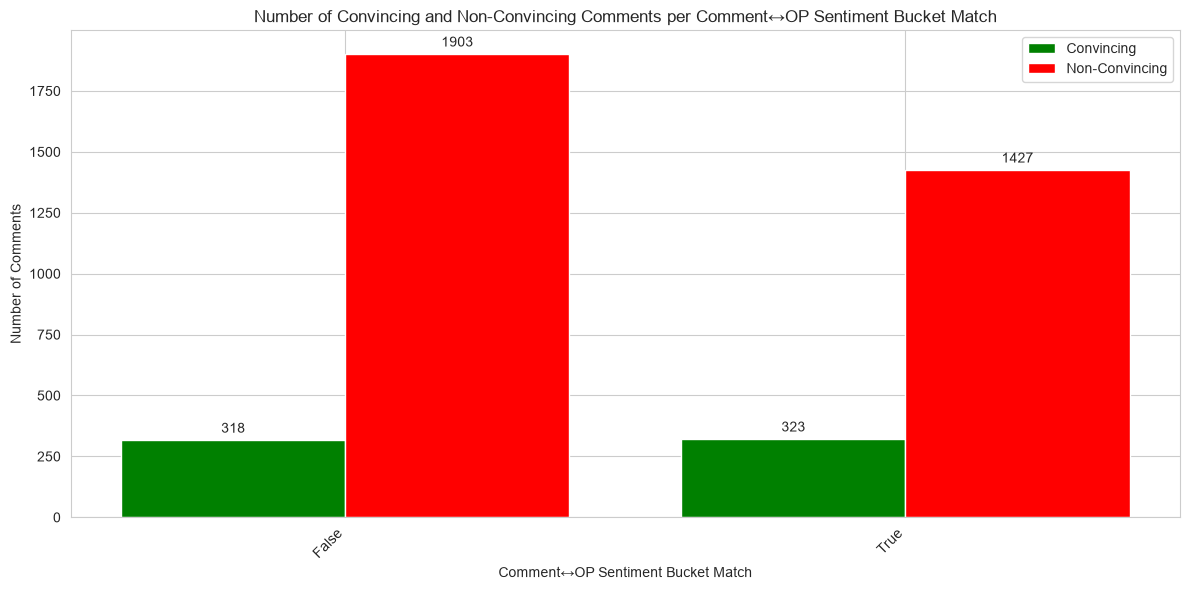

In [35]:
common_functions.plot_category_histogram(comments_df, 'sentiment_match', 'Comment↔OP Sentiment Bucket Match')

Matching sentiment buckets shows a real, if modest, gap: 18.5% convincing (n=1,750) when the comment's sentiment bucket matches the OP's, vs. 14.3% (n=2,221) when it doesn't, against the ~16.1% baseline. That's the same direction as the OP-alone view above, but as a direct two-group comparison rather than a binned trend. We'll keep `sentiment_match` as a feature.

Since `sentiment_llm_op` and `sentiment_llm` are both already features in their own right, it's worth asking whether `sentiment_match` adds anything a model couldn't infer on its own from those two. That depends on the model: we plan to compare logistic regression and SVM alongside tree-based models (random forest, XGBoost), and the linear/margin-based ones only combine inputs additively - they have no built-in way to express "same sign as," so without this column that interaction would be invisible to them no matter how much data they see. Tree-based models can approximate it by splitting on both columns, but need more depth and data to reconstruct what the explicit boolean already states directly. Keeping `sentiment_match` as its own feature makes the interaction available to every model in the comparison, not just the tree-based ones.

## 7.2 Tone

In [ ]:
op_df['tone_google_op'] = None

import re

def get_tone_from_google_ai_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = user_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise common_functions.BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  classifications = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(classifications):
        classifications[i] = label
  return classifications


In [ ]:
BATCH_SIZE = 20

def classify_tone_batch_op(batch_index):
  try:
    classifications = get_tone_from_google_ai_op_batch([op_df.loc[i] for i in batch_index])
    for i, classification in zip(batch_index, classifications):
      op_df.at[i, 'tone_google_op'] = classification
  except common_functions.BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      op_df.at[batch_index[0], 'tone_google_op'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_tone_batch_op(batch_index[:mid])
      classify_tone_batch_op(batch_index[mid:])

pending_index = op_df[op_df['tone_google_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_tone_batch_op(batch_index)
    op_df.to_csv('../results/op_df_tone_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [39]:
none_count = op_df['tone_google_op'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(op_df)}")

All entries were classified!


In [40]:
op_df.to_csv('../results/op_df_tone_checkpoint.csv', index=False)

Same reasoning as 7.1: aggregating to one row per OP gives the same 42.8% mean per-OP convincing rate (computed above), and the same thread-size confound applies to any breakdown by OP tone category here. We'll keep `tone_google_op` as a feature, but rely on the match-based check below rather than this univariate view.

In [45]:
# Does the comment's own tone match the OP's tone label exactly?
comments_df['tone_google_op'] = comments_df['original_post'].map(
    op_df.set_index('original_post')['tone_google_op']
)
comments_df['tone_match'] = comments_df['tone_google'] == comments_df['tone_google_op']
comments_df = comments_df.copy()  # defragment - avoids a pandas PerformanceWarning after many single-column inserts

baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

rate_table = comments_df.groupby('tone_match')['is_convincing'].agg(['mean', 'count'])
rate_table['mean'] = (rate_table['mean'] * 100).round(1)
rate_table.columns = ['convincing_rate_%', 'n']
rate_table

Baseline convincing rate: 16.1%



,convincing_rate_%,n
tone_match,,
False,12.3,2505
True,22.6,1466


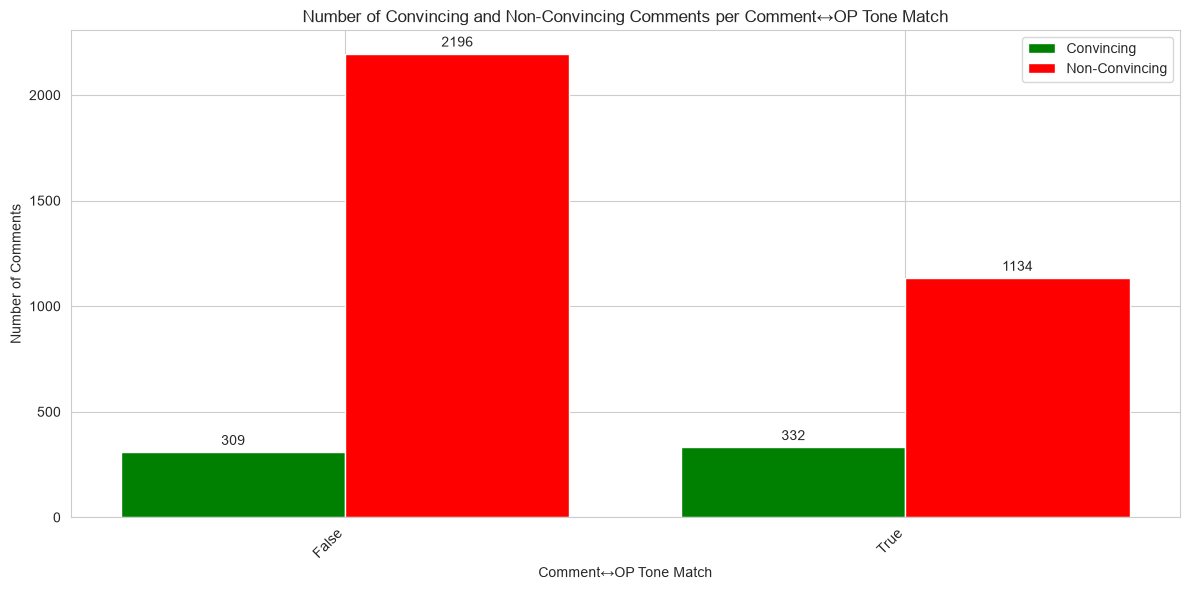

In [46]:
common_functions.plot_category_histogram(comments_df, 'tone_match', 'Comment↔OP Tone Match')

This is the clearest relationship in this notebook so far: comments whose tone matches the OP's tone label convince at 22.6% (n=1,466), vs. 12.3% (n=2,505) when it doesn't, against a ~16.1% baseline. That's a bigger gap than anything in the OP-alone views above, and it fits a mirroring/rapport account of persuasion: meeting the OP's tone (logical-to-logical, passionate-to-passionate, etc.) seems to matter more than the OP's tone by itself. We'll keep `tone_match` as a feature.

## 7.3 Style

*(Carried over from the old `03.2`. `get_style`/`get_style_label` aren't defined in this form yet — `6.3`'s current implementation is batch-based rather than a single-text function. This needs to be reconciled as part of the planned `6.3`/`7.3` rework.)*

In [ ]:
op_df['style_op'] = None

In [ ]:
do_calc_feature_op(op_df, "style_op", get_style)

In [ ]:
op_df['style_label_op'] = op_df['style_op'].apply(get_style_label)

## 7.4 Rhetorical means

Same reasoning as 7.1: Empath's word-list approach already proved unreliable for comments (see 6.4), conflating topic with rhetorical strategy. We skip it here and go straight to the Gemini-based approach.

In [215]:
op_df['ethos_llm_op'] = None
op_df['pathos_llm_op'] = None
op_df['logos_llm_op'] = None

In [216]:
def get_rhetorical_llm_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = rhetorical_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  scores = [(None, None, None)] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)', line)
    if match:
      i = int(match.group(1))
      if 0 <= i < len(scores):
        scores[i] = (float(match.group(2)), float(match.group(3)), float(match.group(4)))
  return scores

In [ ]:
BATCH_SIZE = 20

pending_index = op_df[op_df['ethos_llm_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_rhetorical_llm_op_batch([op_df.loc[i] for i in batch_index])
    for i, (ethos, pathos, logos) in zip(batch_index, scores):
      op_df.at[i, 'ethos_llm_op'] = ethos
      op_df.at[i, 'pathos_llm_op'] = pathos
      op_df.at[i, 'logos_llm_op'] = logos
    op_df.to_csv('../results/op_df_rhetorical_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")

In [218]:
for feature in ['ethos_llm_op', 'pathos_llm_op', 'logos_llm_op']:
  op_df[feature] = pd.to_numeric(op_df[feature], errors='coerce')

op_df[['ethos_llm_op', 'pathos_llm_op', 'logos_llm_op']].describe()

,ethos_llm_op,pathos_llm_op,logos_llm_op
count,401.000000,401.000000,401.000000
mean,0.297007,0.493017,0.702494
std,0.201968,0.206279,0.146437
min,0.000000,0.000000,0.000000
25%,0.100000,0.300000,0.600000
50%,0.300000,0.500000,0.700000
75%,0.400000,0.600000,0.800000
max,0.900000,1.000000,1.000000


## 7.5 Adjective-Adverb Ratio

In [184]:
op_df['adj_adv_ratio_op'] = None

In [ ]:
do_calc_feature_op(op_df, "adj_adv_ratio_op", get_adjective_adverb_ratio)

In [189]:
op_df['adj_adv_ratio_op'].describe()

count     401.0
unique    252.0
top         1.0
freq       14.0
Name: adj_adv_ratio_op, dtype: float64

In [190]:
op_df['adj_adv_ratio_op'].replace(np.inf, 0).astype(float).describe()

count    401.000000
mean       1.625335
std        0.859342
min        0.000000
25%        1.125000
50%        1.444444
75%        1.888889
max        8.666667
Name: adj_adv_ratio_op, dtype: float64

In [191]:
finite_max = op_df['adj_adv_ratio_op'].replace(np.inf, np.nan).max()
sentinel = finite_max + 2  # small margin above the real max keeps infinite-ratio rows the highest without distorting the plot
op_df['adj_adv_ratio_op'] = op_df['adj_adv_ratio_op'].replace(np.inf, sentinel).astype(float)

In [ ]:
op_df['adj_adv_ratio_op'].describe()

## 7.6 Readability - Grade Level

In [ ]:
op_df['fk_grade_level_op'] = None

import textstat
do_calc_feature_op(op_df, "fk_grade_level_op", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

In [ ]:
op_df['fk_grade_level_op'] = pd.to_numeric(op_df['fk_grade_level_op'], errors='coerce')

In [ ]:
op_df['fk_grade_level_op'].describe()

## 7.7 Readability - Reading Ease

In [ ]:
op_df['fk_reading_ease_op'] = None

do_calc_feature_op(op_df, "fk_reading_ease_op", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

In [ ]:
op_df['fk_reading_ease_op'] = pd.to_numeric(op_df['fk_reading_ease_op'], errors='coerce')

In [ ]:
op_df['fk_reading_ease_op'].describe()

## 7.8 Evidence Use

In [ ]:
op_df['evidence_count_op'] = None

do_calc_feature_op(op_df, "evidence_count_op", get_evidence_count)

In [ ]:
op_df['evidence_count_op'] = pd.to_numeric(op_df['evidence_count_op'])

In [ ]:
op_df['evidence_count_op'].describe()

## 7.9 Combine op_df into comments_df

In [ ]:
for index, row in comments_df.iterrows():
    # Find matching original_post in op_df
    matching_rows = op_df[op_df['original_post'] == row['original_post']]

    if matching_rows.empty:
      continue

    # Copy columns from op_df to comments_df
    for col in op_df.columns:
      if col != 'original_post':  # Skip the original_post column itself
        comments_df.loc[index, col] = matching_rows[col].iloc[0]


In [ ]:
comments_df.head()

Let's save the final dataframe.

In [ ]:
comments_df.to_csv('../results/cmv_comments_df.csv', index=False)
print('Saved cmv_comments_df.csv')


In [ ]:
import json
with open('../results/untrusted_features.json', 'w') as f:
    json.dump(untrusted_features, f, indent=2)
print(f'Saved untrusted_features.json: {untrusted_features}')


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation for numeric features only
comments_df_no_embedding = comments_df.loc[:, ~comments_df.columns.str.startswith('embedding_')]
corr_matrix = comments_df_no_embedding.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (w/o embedding features)")
plt.show()